In [1]:
from time import time

import jax.numpy as jnp

from quantum_simulation.jpc_chip import JpcChip
from quantum_simulation.parameters_and_constants import QuantumConstants, SimulationConstants, QuantumParameters

/Users/bradaizakaria/Documents/Xenv/.venv/coeur/lib/python3.11/site-packages/qutip/settings.py:11: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/bradaizakaria/Documents/Xenv/.venv/coeur/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/bradaizakaria/Document

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/bradaizakaria/Documents/Xenv/.venv/coeur/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/bradaizakaria/Documents/Xenv/.venv/coeur/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/bradaizakaria/Documents/Xenv/.venv/coeur/lib/python3.11/site-packages/ipykernel/ker

AttributeError: _ARRAY_API not found

On pose $\hbar = 1$.

**Unités :** 
- Les fréquences et l'Hamiltonien sont données en $\mathrm{MHz}$
- Le temps est donné en  $\mu \mathrm{s} $
- Les $\epsilon$ sont donnés en $ \sqrt{\mathrm{MHz}} $

Dans le référentiel tournant (*Rotating Frame*) l'Hamiltonien du système s'écrit (sans drive) :

$$ H = K_{aa} \left(a^\dagger a \right)^2 + K_{bb} \left(b^\dagger b\right)^2 - K_{ab} \left(a^\dagger a\right) \left( b^\dagger b \right) + g \left( a^\dagger b + a b^\dagger \right) + g_\text{sq} \left( a^\dagger b^\dagger + a b \right) $$

Le *drive* s'exprime dans ce même référentiel :

$$ H_\text{drive} = i \sqrt{\kappa_a}  \left( \epsilon_a^* a - \epsilon_a a^\dagger \right) + i \sqrt{\kappa_b}  \left( \epsilon_b^* b - \epsilon_b b^\dagger \right)   $$

Le *collapse operator* s'exprime :

$$ C = \sqrt{\kappa_a}\; a + \sqrt{\kappa_b}\; b \; \overset{???}{+}\; \sqrt{\kappa_\phi} \;\left( a^\dagger a + b^\dagger b \right) $$


In [6]:
X = jnp.array([-1, -0.7, 0, 0.7, 1, 0.7, 0, -0.7, 1, 1, 1, 1, -1, -1, -1, -1])
#X = jnp.array([1, 1, 1, 1, -1, -1, -1, -1])
params_G = [QuantumParameters(700, 15)]

QP_Dudas = QuantumConstants(
    DIM_A=15,
    DIM_B=15,
    OMEGA_A=1e4,
    OMEGA_B=9 * 1e3,
    KAPPA_A=17,
    KAPPA_B=21,
    K_AA=0.1,
    K_BB=0.1,
    K_AB=0.05,
    EPSILON_A=130,
    EPSILON_B=130,
    DRIVE_DURATION=0.04
)

QP = QP_Dudas

SP = SimulationConstants(10, 150)

chip = JpcChip(QP, SP)



In [7]:
t1 = time()
A = chip.run_simulation(X, params_G)
print(time() - t1)

#c-profile

|██████████| 100.0% ◆ elapsed 34.67s ◆ remaining 0.00ms  


37.97391414642334


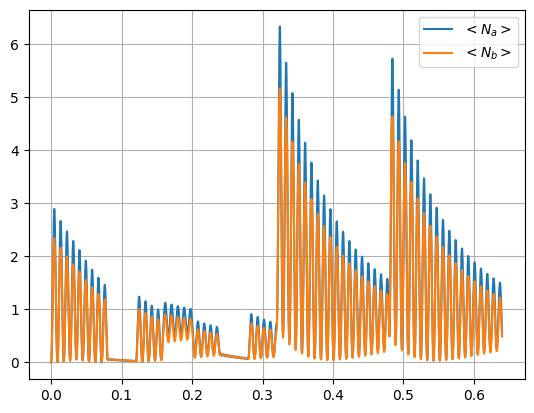

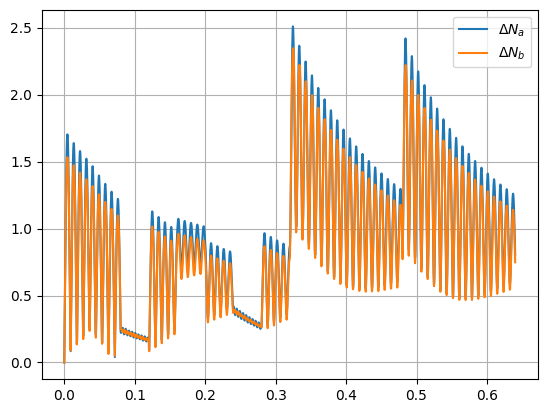

In [8]:
l = A[0].photon_distribution.Plot_Mean_Photon_Number()
l = A[0].photon_distribution.Plot_Sigma_Photon_Number()

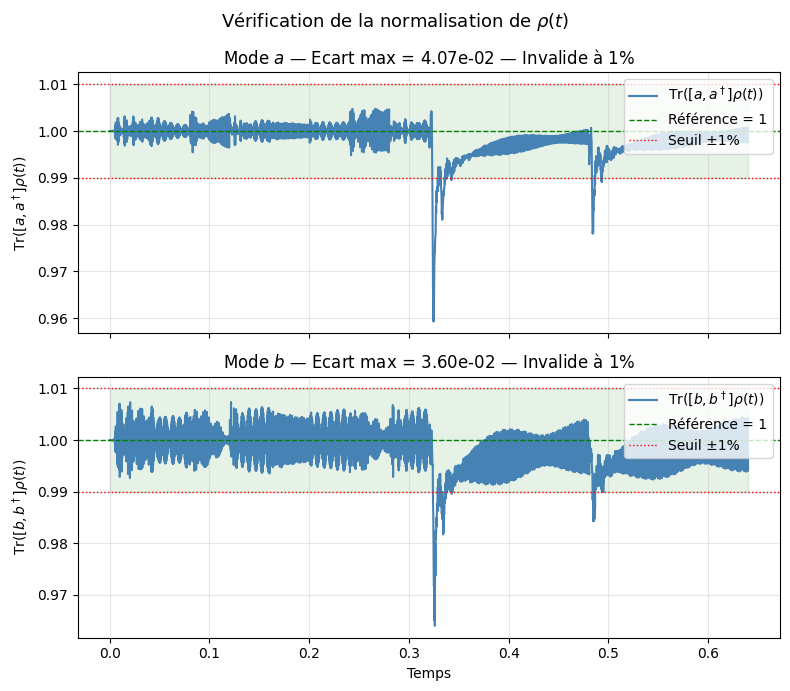

In [10]:
Tr_a, TR_b = A[0].plot_trace_verification()

In [7]:
%matplotlib qt

In [8]:
A[0].photon_distribution.plot_joint_proba()

(<Figure size 1400x1200 with 3 Axes>,
 <matplotlib.widgets.Slider at 0x34d5dbe50>)

In [26]:
A[0].photon_distribution.plot_marginal_proba(mode='a')

(<Figure size 1400x800 with 2 Axes>,
 <matplotlib.widgets.Slider at 0x3356ce4d0>)

In [18]:
A[0].photon_distribution.plot_marginal_proba(mode='b')

(<Figure size 1400x800 with 2 Axes>,
 <matplotlib.widgets.Slider at 0x35f573350>)

In [19]:
A[0].photon_distribution.P_b[-1]

Array([0.07998544, 0.07877594, 0.07611604, 0.07352216, 0.07129832,
       0.06932356, 0.06755143, 0.0658636 , 0.0642262 , 0.0627783 ,
       0.06103722, 0.05976512, 0.0578567 , 0.05615294, 0.05574841],      dtype=float32)

Pour un drive constant (sans effet Kerr et sans JRM) :

$$ \langle N_a \rangle \sim \dfrac{4\epsilon_a^2}{\kappa_a}   $$


Pour un drive constant + JRM (sans effet Kerr) :

$$ \langle N_a \rangle \sim \left[  \dfrac{\sqrt{\kappa_a} \epsilon_a + \dfrac{2 (g_\text{conv} + g_\text{sq}) \epsilon_b}{\sqrt{\kappa_b}} }{\dfrac{2(g_\text{conv} + g_\text{sq})^2}{\kappa_b} - \dfrac{\kappa_a}{2}}    \right]^2  $$
